In [1]:
import pandas as pd

In [2]:
df = pd.read_csv(r'C:\Users\muham\OneDrive\Desktop\bitcoin price prediction\bitcoin_price_prediction Dataset.csv')

In [3]:
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
...,...,...,...,...,...,...,...
2708,2022-02-15,42586.464844,44667.218750,42491.035156,44575.203125,44575.203125,22721659051
2709,2022-02-16,44578.277344,44578.277344,43456.691406,43961.859375,43961.859375,19792547657
2710,2022-02-17,43937.070313,44132.972656,40249.371094,40538.011719,40538.011719,26246662813
2711,2022-02-18,40552.132813,40929.152344,39637.617188,40030.976563,40030.976563,23310007704


<span style="color: #FF6B6B;">FEATURE  ENGINEERING</span>


In [4]:
# OPEN ---> Lots of outliers are there in the OPEN column (we can use log transformation )
# High ---> Lots of outliers are there in the HIGH column (we can use log transformation )

In [5]:
df[df['Close'] == df['Adj Close']].shape

(2713, 7)

In [6]:
df.head(1)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800


In [7]:
df['Date'] = df['Date'].astype('datetime64[ns]')

In [8]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['day'] = df['Date'].dt.day


In [9]:
df.drop(columns=['Adj Close','Date'], inplace=True)

In [10]:
df.head()

,Open,High,Low,Close,Volume,year,month,day
0,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17
1,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18
2,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19
3,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20
4,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21



<span style="color: #d42000;">OPEN FEATURE</span>  

In [11]:
import matplotlib.pyplot as plt

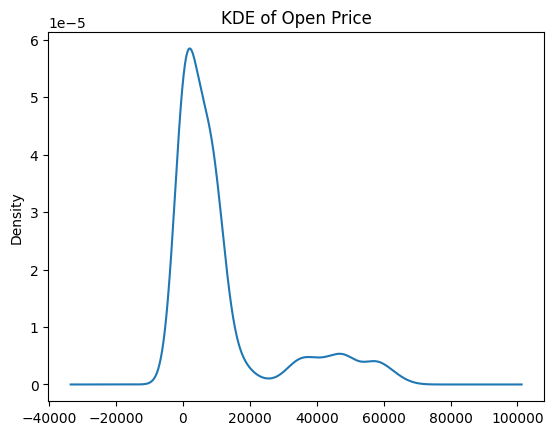

In [12]:
df['Open'].plot.kde()
plt.title('KDE of Open Price')
plt.show()

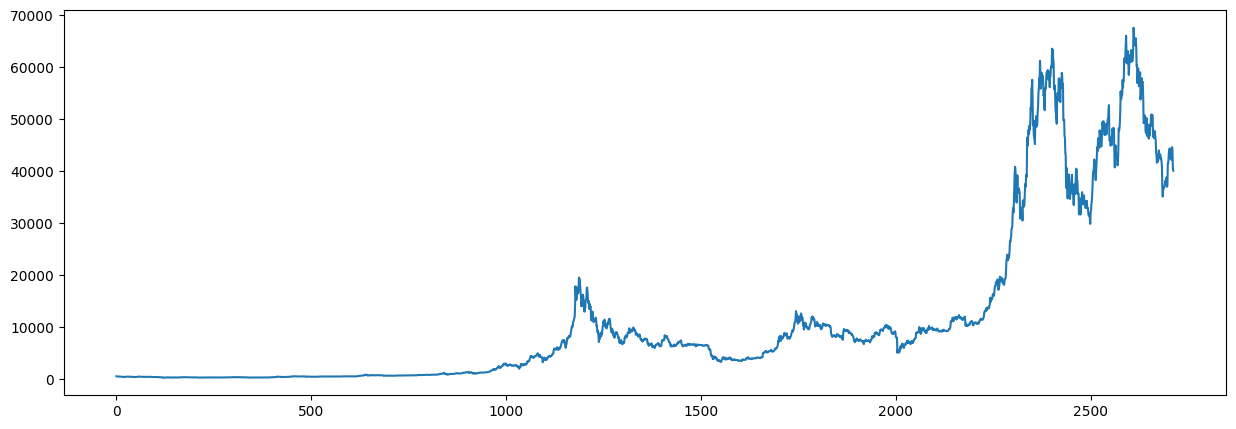

In [13]:

plt.figure(figsize=(15,5))
plt.plot(df['Open'], label='Open')

In [14]:
df['year'].unique()

array([2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022], dtype=int32)

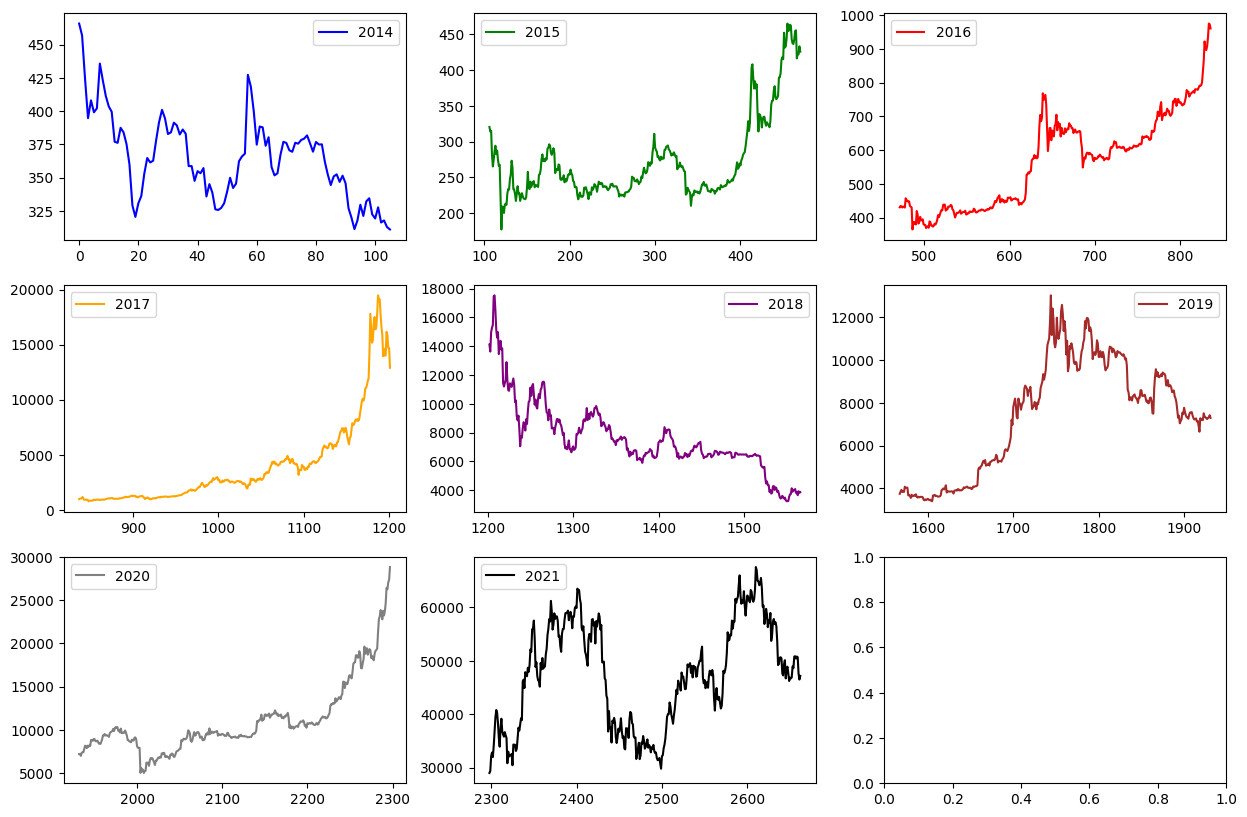

In [15]:
fig , ax = plt.subplots(nrows=3,ncols=3,figsize=(15,10))
ax[0][0].plot(df[df['year'] == 2014]['Open'], label='2014',color='blue')
ax[0][0].legend()
ax[0][1].plot(df[df['year'] == 2015]['Open'], label='2015',color='green')
ax[0][1].legend()
ax[0][2].plot(df[df['year'] == 2016]['Open'], label='2016',color='red')
ax[0][2].legend()
ax[1][0].plot(df[df['year'] == 2017]['Open'], label='2017',color='orange')
ax[1][0].legend()
ax[1][1].plot(df[df['year'] == 2018]['Open'], label='2018',color='purple')
ax[1][1].legend()
ax[1][2].plot(df[df['year'] == 2019]['Open'], label='2019',color='brown')
ax[1][2].legend()
ax[2][0].plot(df[df['year'] == 2020]['Open'], label='2020',color='gray')
ax[2][0].legend()
ax[2][1].plot(df[df['year'] == 2021]['Open'], label='2021',color='black')
ax[2][1].legend()
plt.show()


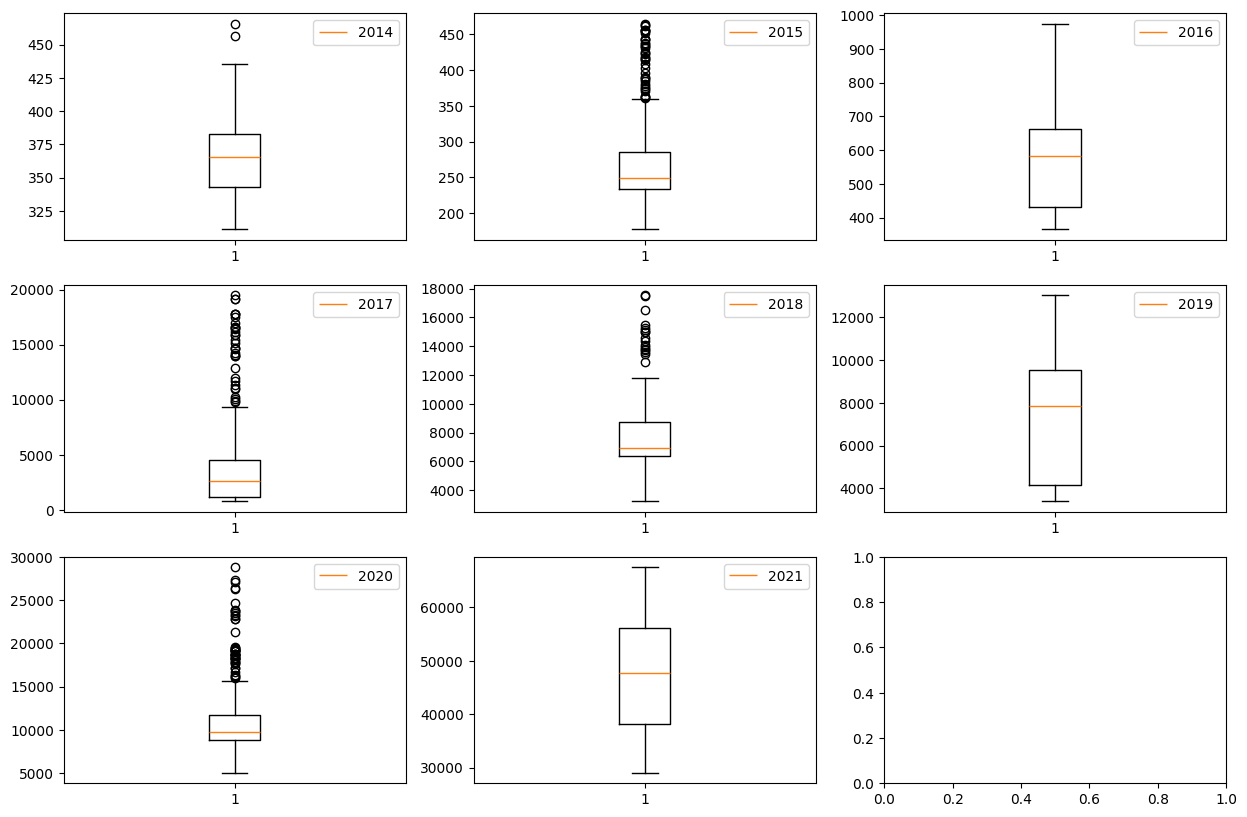

In [16]:
fig , ax = plt.subplots(nrows=3,ncols=3,figsize=(15,10))
ax[0][0].boxplot(df[df['year'] == 2014]['Open'], label='2014')
ax[0][0].legend()
ax[0][1].boxplot(df[df['year'] == 2015]['Open'], label='2015')
ax[0][1].legend()
ax[0][2].boxplot(df[df['year'] == 2016]['Open'], label='2016')
ax[0][2].legend()
ax[1][0].boxplot(df[df['year'] == 2017]['Open'], label='2017')
ax[1][0].legend()
ax[1][1].boxplot(df[df['year'] == 2018]['Open'], label='2018')
ax[1][1].legend()
ax[1][2].boxplot(df[df['year'] == 2019]['Open'], label='2019')
ax[1][2].legend()
ax[2][0].boxplot(df[df['year'] == 2020]['Open'], label='2020')
ax[2][0].legend()
ax[2][1].boxplot(df[df['year'] == 2021]['Open'], label='2021')
ax[2][1].legend()
plt.show()

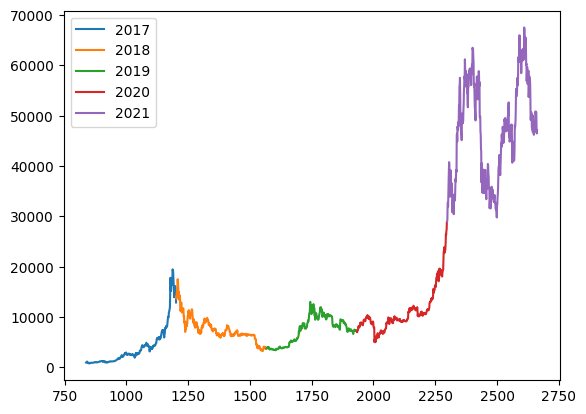

In [17]:
plt.plot(df[df['year'] == 2017]['Open'], label='2017')
plt.legend()
plt.plot(df[df['year'] == 2018]['Open'], label='2018')
plt.legend()
plt.plot(df[df['year'] == 2019]['Open'], label='2019')
plt.legend()
plt.plot(df[df['year'] == 2020]['Open'], label='2020')
plt.legend()
plt.plot(df[df['year'] == 2021]['Open'], label='2021')
plt.legend()
plt.show()

In [18]:
df['Open'].describe()

count     2713.000000
mean     11311.041069
std      16106.428891
min        176.897003
25%        606.396973
50%       6301.569824
75%      10452.399414
max      67549.734375
Name: Open, dtype: float64

In [19]:
df.head(2)

,Open,High,Low,Close,Volume,year,month,day
0,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17
1,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18






<p style="color: orange;">HIGH FEQTURE</p>

In [20]:
df['High'].describe()

count     2713.000000
mean     11614.292482
std      16537.390649
min        211.731003
25%        609.260986
50%       6434.617676
75%      10762.644531
max      68789.625000
Name: High, dtype: float64

In [21]:
df['High'].isnull().sum()

np.int64(0)

<Axes: ylabel='High'>

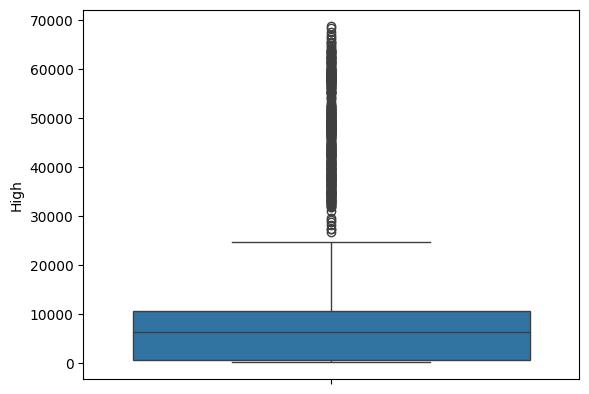

In [22]:
import seaborn as sns
sns.boxplot(df['High'])

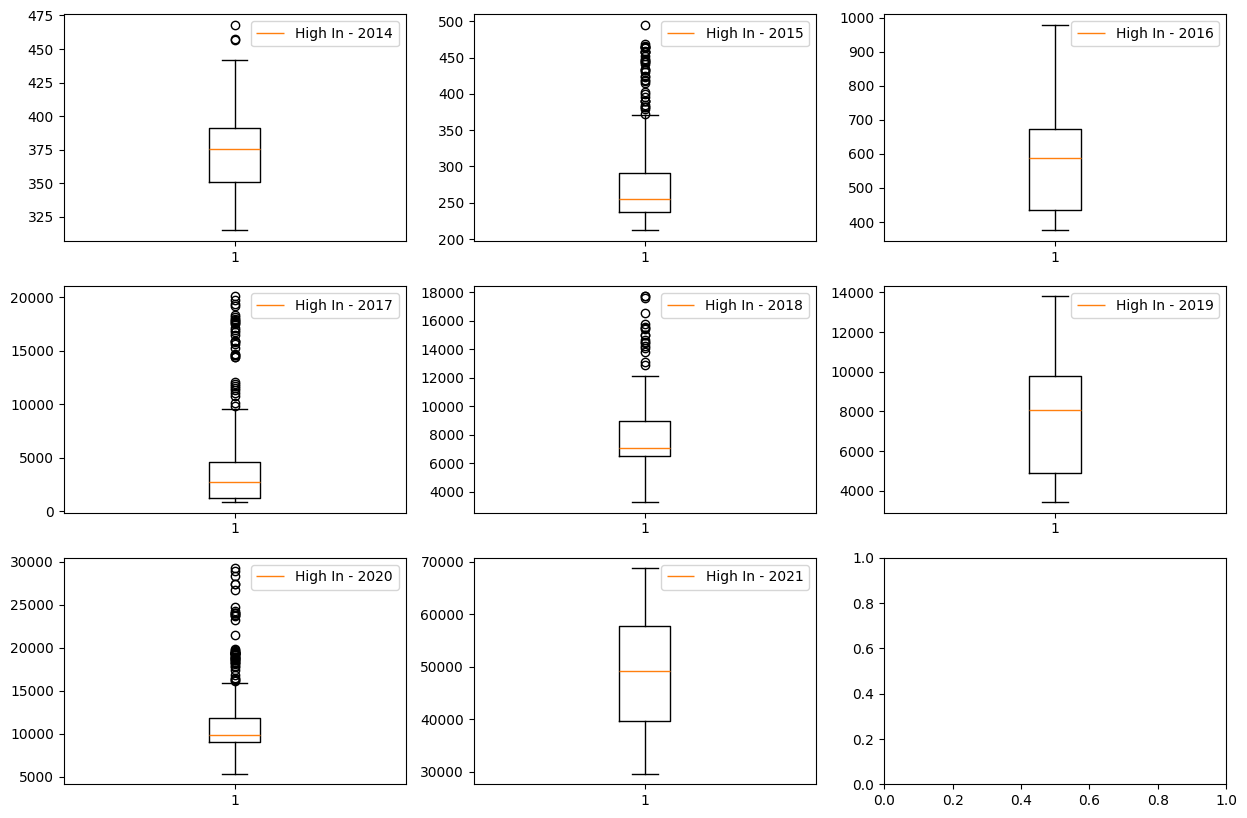

In [23]:
fig , ax = plt.subplots(nrows=3,ncols=3,figsize=(15,10))
ax[0][0].boxplot(df[df['year'] == 2014]['High'], label='High In - 2014')
ax[0][0].legend()
ax[0][1].boxplot(df[df['year'] == 2015]['High'], label='High In - 2015')
ax[0][1].legend()
ax[0][2].boxplot(df[df['year'] == 2016]['High'], label='High In - 2016')
ax[0][2].legend()
ax[1][0].boxplot(df[df['year'] == 2017]['High'], label='High In - 2017')
ax[1][0].legend()
ax[1][1].boxplot(df[df['year'] == 2018]['High'], label='High In - 2018')
ax[1][1].legend()
ax[1][2].boxplot(df[df['year'] == 2019]['High'], label='High In - 2019')
ax[1][2].legend()
ax[2][0].boxplot(df[df['year'] == 2020]['High'], label='High In - 2020')
ax[2][0].legend()
ax[2][1].boxplot(df[df['year'] == 2021]['High'], label='High In - 2021')
ax[2][1].legend()
plt.show()

In [24]:
df.head(1)

,Open,High,Low,Close,Volume,year,month,day
0,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17


<Axes: xlabel='High', ylabel='Density'>

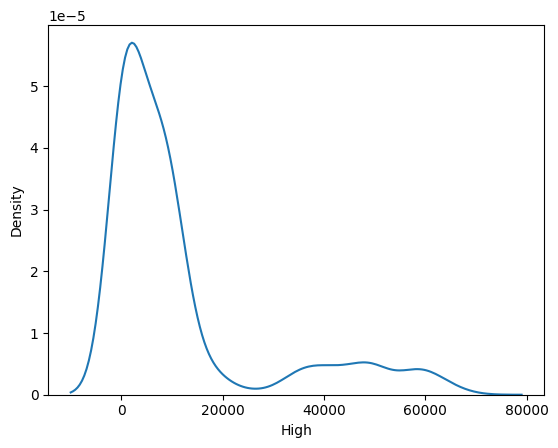

In [25]:
import seaborn as sns
sns.kdeplot(df['High'])

In [26]:
print(df['High'].info())
print(df['High'].describe())

<class 'pandas.Series'>
RangeIndex: 2713 entries, 0 to 2712
Series name: High
Non-Null Count  Dtype  
--------------  -----  
2713 non-null   float64
dtypes: float64(1)
memory usage: 21.3 KB
None
count     2713.000000
mean     11614.292482
std      16537.390649
min        211.731003
25%        609.260986
50%       6434.617676
75%      10762.644531
max      68789.625000
Name: High, dtype: float64


In [27]:
df['High']

0         468.174011
1         456.859985
2         427.834991
3         423.295990
4         412.425995
            ...     
2708    44667.218750
2709    44578.277344
2710    44132.972656
2711    40929.152344
2712    40246.027344
Name: High, Length: 2713, dtype: float64

In [28]:
df.head()

,Open,High,Low,Close,Volume,year,month,day
0,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17
1,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18
2,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19
3,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20
4,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21


<span style="color: #d42000;">LOW FEATURE</span>   

In [29]:
df['Low'].describe()

count     2713.000000
mean     10975.555057
std      15608.572560
min        171.509995
25%        604.109985
50%       6214.220215
75%      10202.387695
max      66382.062500
Name: Low, dtype: float64

<Axes: ylabel='Low'>

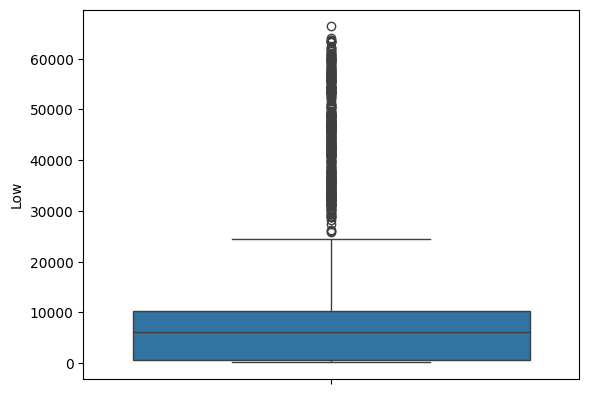

In [30]:
sns.boxplot(df['Low'])

In [31]:
df['Low'].isnull().sum()

np.int64(0)

In [32]:
df


,Open,High,Low,Close,Volume,year,month,day
0,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17
1,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18
2,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19
3,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20
4,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21
...,...,...,...,...,...,...,...,...
2708,42586.464844,44667.218750,42491.035156,44575.203125,22721659051,2022,2,15
2709,44578.277344,44578.277344,43456.691406,43961.859375,19792547657,2022,2,16
2710,43937.070313,44132.972656,40249.371094,40538.011719,26246662813,2022,2,17
2711,40552.132813,40929.152344,39637.617188,40030.976563,23310007704,2022,2,18


In [33]:
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df['quarter_end'] = df['date'].dt.is_quarter_end.astype(int)
df.drop(columns=['date'], inplace=True)

In [34]:
df['quarter_end'].value_counts()

quarter_end
0    2683
1      30
Name: count, dtype: int64

<Axes: ylabel='Density'>

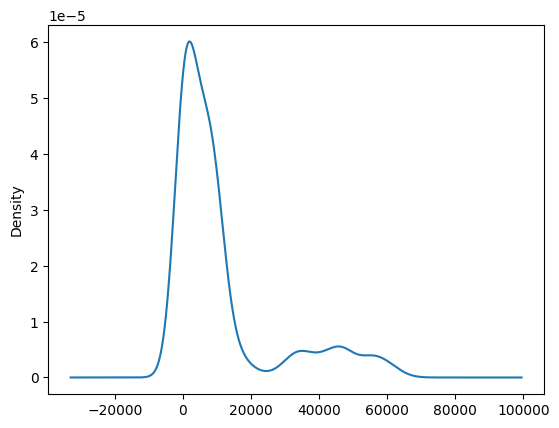

In [35]:
df['Low'].plot.kde()

<span style="color: #d42000;">Close FEATURE</span>   

<Axes: ylabel='Density'>

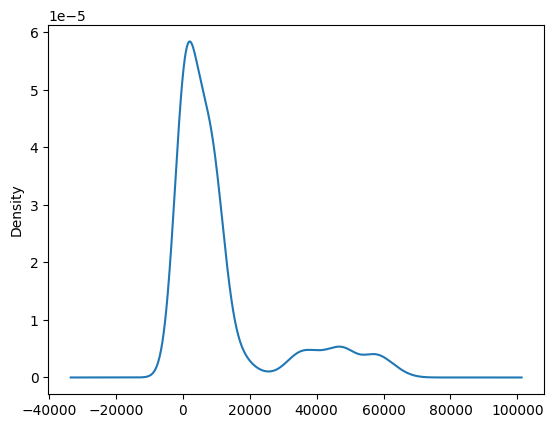

In [36]:
df['Close'].plot.kde()

In [37]:
df.head()

,Open,High,Low,Close,Volume,year,month,day,quarter_end
0,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,0
1,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,0
2,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,0
3,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,0
4,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,0


<Axes: ylabel='Close'>

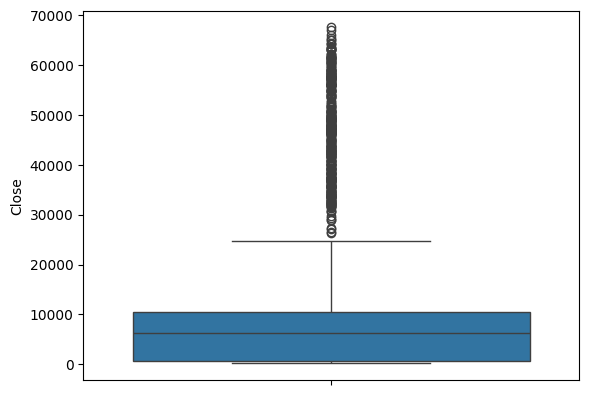

In [38]:
sns.boxplot(df['Close'])

In [39]:
df['date'] = pd.to_datetime(df[['year','month','day']])
df['day_of_week'] = df['date'].dt.dayofweek
df['quarter']     = df['date'].dt.quarter
df.drop(columns=['date'], inplace=True)

In [40]:
df.head()

,Open,High,Low,Close,Volume,year,month,day,quarter_end,day_of_week,quarter
0,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,0,2,3
1,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,0,3,3
2,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,0,4,3
3,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,0,5,3
4,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,0,6,3


In [41]:
df['returns'] = df['Close'].pct_change()

In [42]:
df.tail()

,Open,High,Low,Close,Volume,year,month,day,quarter_end,day_of_week,quarter,returns
2708,42586.464844,44667.218750,42491.035156,44575.203125,22721659051,2022,2,15,0,1,1,0.046688
2709,44578.277344,44578.277344,43456.691406,43961.859375,19792547657,2022,2,16,0,2,1,-0.013760
2710,43937.070313,44132.972656,40249.371094,40538.011719,26246662813,2022,2,17,0,3,1,-0.077882
2711,40552.132813,40929.152344,39637.617188,40030.976563,23310007704,2022,2,18,0,4,1,-0.012508
2712,40022.132813,40246.027344,40010.867188,40126.429688,22263900160,2022,2,19,0,5,1,0.002384


In [43]:
df.corr()

,Open,High,Low,Close,Volume,year,month,day,quarter_end,day_of_week,quarter,returns
Open,1.000000e+00,0.999535,0.999103,0.998839,0.728537,0.753127,-0.004499,-0.010592,-0.004454,-6.886744e-07,-0.002131,-0.020240
High,9.995354e-01,1.000000,0.999046,0.999489,0.732137,0.752784,-0.005756,-0.010632,-0.004473,-1.474984e-03,-0.003461,-0.004929
Low,9.991026e-01,0.999046,1.000000,0.999399,0.720922,0.753955,-0.001716,-0.011555,-0.004005,1.730373e-03,0.001009,-0.002187
Close,9.988395e-01,0.999489,0.999399,1.000000,0.727443,0.753472,-0.004284,-0.011802,-0.004278,1.904065e-04,-0.001712,0.009894
Volume,7.285365e-01,0.732137,0.720922,0.727443,1.000000,0.763144,-0.114131,-0.000412,-0.004660,-3.063914e-02,-0.114596,0.001532
year,7.531273e-01,0.752784,0.753955,0.753472,0.763144,1.000000,-0.135228,-0.016935,-0.008996,1.844733e-04,-0.130622,0.005504
month,-4.498661e-03,-0.005756,-0.001716,-0.004284,-0.114131,-0.135228,1.000000,0.018533,0.033220,-1.421607e-03,0.972629,0.015440
day,-1.059169e-02,-0.010632,-0.011555,-0.011802,-0.000412,-0.016935,0.018533,1.000000,0.177426,8.283253e-04,0.019224,-0.013955
quarter_end,-4.454256e-03,-0.004473,-0.004005,-0.004278,-0.004660,-0.008996,0.033220,0.177426,1.000000,1.724196e-03,0.003062,0.014801
day_of_week,-6.886744e-07,-0.001475,0.001730,0.000190,-0.030639,0.000184,-0.001422,0.000828,0.001724,1.000000e+00,-0.000173,-0.021463


<Axes: >

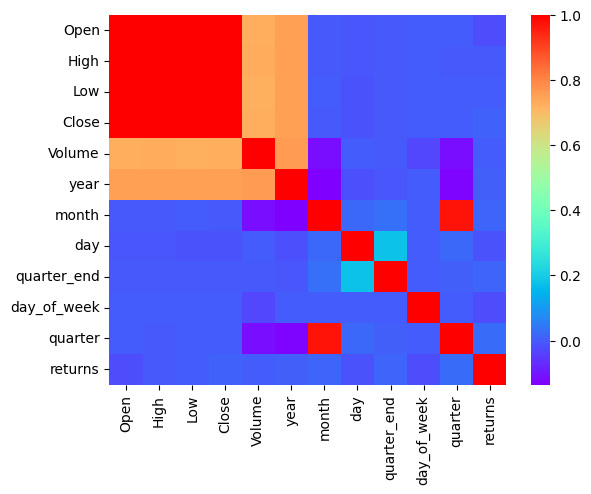

In [44]:
sns.heatmap(df.corr(),  cmap='rainbow')

In [45]:
df['SMA_5']  = df['Close'].rolling(5).mean()
df['SMA_20'] = df['Close'].rolling(20).mean()

In [46]:
df['returns_lag1'] = df['returns'].shift(1)
df['returns_lag3'] = df['returns'].shift(3)
df['returns_lag7'] = df['returns'].shift(7)

In [47]:
import numpy as np

In [48]:
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

In [49]:
df.head()

,Open,High,Low,Close,Volume,year,month,day,quarter_end,day_of_week,quarter,returns,SMA_5,SMA_20,returns_lag1,returns_lag3,returns_lag7,target
0,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,0,2,3,NaN,NaN,NaN,NaN,NaN,NaN,0
1,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,0,3,3,-0.071926,NaN,NaN,NaN,NaN,NaN,0
2,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,0,4,3,-0.069843,NaN,NaN,-0.071926,NaN,NaN,1
3,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,0,5,3,0.035735,NaN,NaN,-0.069843,NaN,NaN,0
4,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,0,6,3,-0.024659,416.859003,NaN,0.035735,-0.071926,NaN,1


In [50]:
df.isnull().sum()

Open             0
High             0
Low              0
Close            0
Volume           0
year             0
month            0
day              0
quarter_end      0
day_of_week      0
quarter          0
returns          1
SMA_5            4
SMA_20          19
returns_lag1     2
returns_lag3     4
returns_lag7     8
target           0
dtype: int64

In [51]:
df.dropna(inplace=True)

In [52]:
df.shape

(2694, 18)

In [53]:
df

,Open,High,Low,Close,Volume,year,month,day,quarter_end,day_of_week,quarter,returns,SMA_5,SMA_20,returns_lag1,returns_lag3,returns_lag7,target
19,320.389008,345.134003,302.559998,330.079010,79011800,2014,10,6,0,0,4,0.029856,342.807800,389.910399,-0.025408,-0.041485,-0.004544,1
20,330.584015,339.247009,320.481995,336.187012,49199900,2014,10,7,0,1,4,0.018505,335.030804,383.853049,0.029856,-0.085243,0.030567,1
21,336.115997,354.364014,327.187988,352.940002,54736300,2014,10,8,0,2,4,0.049832,333.716406,380.278049,0.018505,-0.025408,-0.008603,1
22,352.747986,382.726013,347.687012,365.026001,83641104,2014,10,9,0,3,4,0.034244,340.948407,378.789549,0.049832,0.029856,-0.022270,0
23,364.687012,375.066986,352.963013,361.562012,43665700,2014,10,10,0,4,4,-0.009490,349.158807,376.422450,0.034244,0.018505,-0.041485,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2708,42586.464844,44667.218750,42491.035156,44575.203125,22721659051,2022,2,15,0,1,1,0.046688,42802.408594,40877.074414,0.009228,-0.003855,0.006345,0
2709,44578.277344,44578.277344,43456.691406,43961.859375,19792547657,2022,2,16,0,2,1,-0.013760,43113.192969,41218.255664,0.046688,-0.001111,0.004995,0
2710,43937.070313,44132.972656,40249.371094,40538.011719,26246662813,2022,2,17,0,3,1,-0.077882,42771.901563,41355.939649,-0.013760,0.009228,-0.017449,0
2711,40552.132813,40929.152344,39637.617188,40030.976563,23310007704,2022,2,18,0,4,1,-0.012508,42338.593750,41450.579492,-0.077882,0.046688,-0.026562,1


In [54]:
from sklearn.model_selection import train_test_split

In [55]:
df['target'].value_counts()

target
1    1464
0    1230
Name: count, dtype: int64

In [56]:
x = df.drop(columns=['target'])
y = df['target']

In [57]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [58]:
df['returns_lag7'].min()

np.float64(-0.3716953856106434)

In [59]:
x_train

,Open,High,Low,Close,Volume,year,month,day,quarter_end,day_of_week,quarter,returns,SMA_5,SMA_20,returns_lag1,returns_lag3,returns_lag7
1441,6891.080078,7109.560059,6882.339844,7096.279785,4659940000,2018,8,28,0,1,3,0.030741,6834.265918,6495.127905,0.026446,0.006433,0.028569
1892,7643.569336,7697.382813,6936.706543,7296.577637,34242315785,2019,11,22,0,4,4,-0.045294,7896.405469,8674.274414,-0.047901,-0.012413,-0.024816
1933,7202.551270,7212.155273,6935.270020,6985.470215,20802083465,2020,1,2,0,3,1,-0.029819,7218.978320,7207.321777,0.000914,-0.017468,-0.004974
76,379.250000,384.037994,377.863007,381.315002,12364100,2014,12,2,0,1,4,0.005458,378.108996,376.787196,0.003169,-0.002540,-0.004120
2651,46707.062500,47401.718750,45579.808594,46880.277344,30961902129,2021,12,20,0,0,4,0.003710,46860.728125,49429.484766,-0.003026,-0.030699,-0.067085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1657,4105.362305,4164.953125,4096.901367,4158.183105,10157794171,2019,4,1,0,0,2,0.012856,4107.545850,4037.068140,-0.000306,0.007193,-0.014693
1114,4229.879883,4362.640137,4164.049805,4328.410156,1161769984,2017,10,5,0,3,4,0.023420,4337.662011,4011.246484,-0.020410,0.001267,-0.006175
1149,7446.830078,7446.830078,7101.520020,7143.580078,3226249984,2017,11,9,0,3,4,-0.042376,7235.563965,6502.535962,0.044134,-0.051928,0.045984
1313,8925.059570,9001.639648,8779.610352,8802.459961,6629899776,2018,4,22,0,6,2,-0.010468,8600.319922,7666.453955,0.005624,0.016034,0.042933


In [60]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, MinMaxScaler

In [61]:
col_tra = ColumnTransformer(transformers=[
    ('robust',MinMaxScaler(),['Open','High','Low','Close','Volume','year','quarter','SMA_5','SMA_20']),
    ('minmax',MinMaxScaler(),['month','day','day_of_week'])

],remainder='passthrough')

In [62]:
x_train_tran = pd.DataFrame(
    col_tra.fit_transform(x_train),
    columns=x_train.columns
)
x_test_tran  = pd.DataFrame(
    col_tra.transform(x_test),
    columns=x_test.columns 
)

In [63]:
x_train_tran

,Open,High,Low,Close,Volume,year,month,day,quarter_end,day_of_week,quarter,returns,SMA_5,SMA_20,returns_lag1,returns_lag3,returns_lag7
0,0.099657,0.100584,0.101283,0.102379,0.037741,0.500,0.666667,0.101185,0.099626,0.636364,0.900000,0.166667,0.0,0.030741,0.026446,0.006433,0.028569
1,0.110826,0.109155,0.102104,0.105352,0.277634,0.625,1.000000,0.117395,0.134258,0.909091,0.700000,0.666667,0.0,-0.045294,-0.047901,-0.012413,-0.024816
2,0.104280,0.102080,0.102082,0.100734,0.168643,0.750,0.000000,0.107057,0.110944,0.000000,0.033333,0.500000,0.0,-0.029819,0.000914,-0.017468,-0.004974
3,0.003003,0.002513,0.003036,0.002702,0.000052,0.000,1.000000,0.002654,0.002390,1.000000,0.033333,0.166667,0.0,0.005458,0.003169,-0.002540,-0.004120
4,0.690637,0.688122,0.685791,0.692930,0.251033,0.875,1.000000,0.712055,0.781958,1.000000,0.633333,0.000000,0.0,0.003710,-0.003026,-0.030699,-0.067085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,0.058309,0.057646,0.059210,0.058766,0.082325,0.625,0.333333,0.059571,0.060561,0.272727,0.000000,0.000000,0.0,0.012856,-0.000306,0.007193,-0.014693
2151,0.060158,0.060528,0.060224,0.061293,0.009373,0.375,1.000000,0.063083,0.060151,0.818182,0.133333,0.500000,0.0,0.023420,-0.020410,0.001267,-0.006175
2152,0.107906,0.105502,0.104593,0.103081,0.026115,0.375,1.000000,0.107310,0.099743,0.909091,0.266667,0.500000,0.0,-0.042376,0.044134,-0.051928,0.045984
2153,0.129847,0.128174,0.129940,0.127705,0.053716,0.500,0.333333,0.128138,0.118241,0.272727,0.700000,1.000000,0.0,-0.010468,0.005624,0.016034,0.042933


In [64]:
from sklearn.ensemble import RandomForestClassifier

In [65]:
Model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
)
Model.fit(x_train_tran,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [66]:
feat_importance = pd.DataFrame(Model.feature_importances_, index=x_train_tran.columns)

In [67]:
import matplotlib.pyplot as plt

<Figure size 1000x800 with 0 Axes>

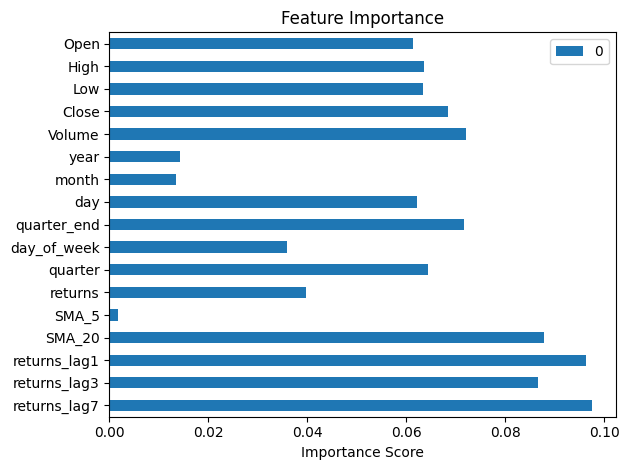

In [68]:
plt.figure(figsize=(10, 8))
feat_importance.plot(kind='barh')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()  # most important upar dikhe
plt.tight_layout()
plt.show()

In [69]:
#  We can observe that SMA_5 , Month and Year are not bringing any value into the table. so we can drop them and train the model again to see if there is any improvement in the accuracy of the model or not.

In [70]:
cols = x_train_tran.columns
for col in cols:
    if col in ['SMA_5','month','year']:
        x_train_tran.drop(columns=[col], inplace=True)
        x_test_tran.drop(columns=[col], inplace=True)

In [71]:
x_train_tran

,Open,High,Low,Close,Volume,day,quarter_end,day_of_week,quarter,returns,SMA_20,returns_lag1,returns_lag3,returns_lag7
0,0.099657,0.100584,0.101283,0.102379,0.037741,0.101185,0.099626,0.636364,0.900000,0.166667,0.030741,0.026446,0.006433,0.028569
1,0.110826,0.109155,0.102104,0.105352,0.277634,0.117395,0.134258,0.909091,0.700000,0.666667,-0.045294,-0.047901,-0.012413,-0.024816
2,0.104280,0.102080,0.102082,0.100734,0.168643,0.107057,0.110944,0.000000,0.033333,0.500000,-0.029819,0.000914,-0.017468,-0.004974
3,0.003003,0.002513,0.003036,0.002702,0.000052,0.002654,0.002390,1.000000,0.033333,0.166667,0.005458,0.003169,-0.002540,-0.004120
4,0.690637,0.688122,0.685791,0.692930,0.251033,0.712055,0.781958,1.000000,0.633333,0.000000,0.003710,-0.003026,-0.030699,-0.067085
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2150,0.058309,0.057646,0.059210,0.058766,0.082325,0.059571,0.060561,0.272727,0.000000,0.000000,0.012856,-0.000306,0.007193,-0.014693
2151,0.060158,0.060528,0.060224,0.061293,0.009373,0.063083,0.060151,0.818182,0.133333,0.500000,0.023420,-0.020410,0.001267,-0.006175
2152,0.107906,0.105502,0.104593,0.103081,0.026115,0.107310,0.099743,0.909091,0.266667,0.500000,-0.042376,0.044134,-0.051928,0.045984
2153,0.129847,0.128174,0.129940,0.127705,0.053716,0.128138,0.118241,0.272727,0.700000,1.000000,-0.010468,0.005624,0.016034,0.042933


In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [73]:
y_train

1441    0
1892    1
1933    1
76      0
2651    1
       ..
1657    1
1114    1
1149    0
1313    1
879     0
Name: target, Length: 2155, dtype: int64

In [74]:
from sklearn.metrics import precision_score

In [75]:
models = [model for model in [LogisticRegression(class_weight='balanced'), RandomForestClassifier(class_weight='balanced'), SVC(class_weight='balanced'), KNeighborsClassifier()]]
print(models)
for model in models:
    print(model)
    model.fit(x_train_tran,y_train)
    y_pred = model.predict(x_test_tran)
    print(model.score(x_test_tran,y_test))
    print(classification_report(y_test,y_pred))
    print('Accuracy Score:', accuracy_score(y_test, y_pred))
    print('Precision Score:', precision_score(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))


[LogisticRegression(class_weight='balanced'), RandomForestClassifier(class_weight='balanced'), SVC(class_weight='balanced'), KNeighborsClassifier()]
LogisticRegression(class_weight='balanced')
0.5120593692022264
              precision    recall  f1-score   support

           0       0.45      0.35      0.40       245
           1       0.54      0.65      0.59       294

    accuracy                           0.51       539
   macro avg       0.50      0.50      0.49       539
weighted avg       0.50      0.51      0.50       539

Accuracy Score: 0.5120593692022264
Precision Score: 0.5444126074498568
[[ 86 159]
 [104 190]]
RandomForestClassifier(class_weight='balanced')
0.5306122448979592
              precision    recall  f1-score   support

           0       0.48      0.38      0.43       245
           1       0.56      0.65      0.60       294

    accuracy                           0.53       539
   macro avg       0.52      0.52      0.51       539
weighted avg       0.52     

In [76]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

# Step 1: Define the param grid
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 5, 10, None],
    'model__min_samples_split': [2, 5, 10],
    'model__class_weight': ['balanced']   # fixed — not tuning this
}

# Step 2: Build pipeline (scaler + model)
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

# Step 3: Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,                    # 5-fold cross-validation
    scoring='f1',            # since tumhara data imbalanced hai
    n_jobs=-1,               # use all CPU cores
    verbose=2,               # progress print karo
    refit=True               # best model ko full data pe retrain karo
)

# Step 4: Fit
grid_search.fit(x_train, y_train)

# Step 5: Results
print("Best params:", grid_search.best_params_)
print("Best CV F1:", grid_search.best_score_.round(4))

# Step 6: Predict using best model (automatically refit)
y_pred = grid_search.predict(x_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params: {'model__class_weight': 'balanced', 'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV F1: 0.6042


In [77]:
# hyperparameter tuning for XGBoost
from xgboost import XGBClassifier

In [78]:
# param_grid = {
#     # Trees & learning
#     'n_estimators':   [100, 300, 500],
#     'learning_rate':  [0.01, 0.05, 0.1],

#     # Tree structure (overfitting control)
#     'max_depth':      [3, 5, 7],
#     'min_child_weight': [1, 3, 5],

#     # Randomization (like RF's max_features)
#     'subsample':        [0.7, 0.9],
#     'colsample_bytree': [0.7, 0.9],

#     # Regularization
#     'gamma':      [0, 0.1, 0.3],
#     'reg_alpha':  [0, 0.1],      
#     'reg_lambda': [1, 1.5],      
# }


# neg = (y_train == 0).sum()
# pos = (y_train == 1).sum()
# spw = neg / pos

# model = XGBClassifier(
#     scale_pos_weight=spw,  
#     eval_metric='logloss',  
#     random_state=42,
#     n_jobs=-1
# )
# grid_search = GridSearchCV(
#     estimator=model,
#     param_grid=param_grid,
#     cv=5,                   
#     scoring='f1',            
#     n_jobs=-1,             
#     verbose=2,              
#     refit=True               
# )

# grid_search.fit(x_train, y_train)
# print("Best params:", grid_search.best_params_)
# print("Best CV F1:", grid_search.best_score_.round(4))

# # Step 6: Predict using best model (automatically refit)
# y_pred = grid_search.predict(x_test)